# Dataset Rebalancing — Opsi B (Cap Total + Tiered Balance)
**Project:** Noise-Aware Federated Learning for Robust Diabetic Retinopathy Classification

Pipeline: NPZ → Inspect distribusi label → Tiered undersample → Save 3 NPZ baru

## Strategi: Opsi B
Skala total dataset disesuaikan mendekati reference paper (Mohan Raj et al.), tetapi
distribusi per kelas di-balance secara tiered agar model tidak bias ke kelas mayoritas.
**Semua 5 kelas (0–4) dipertahankan** di setiap dataset output.

| Dataset | Total Reference | Target Output | Strategi |
|---------|----------------|---------------|----------|
| DDR | ~12,256 | ~11,000 | General balance (cap ke minority terbanyak) |
| EyePACS | ~11,673 | ~11,000 | Tiered agresif (kelas 0 dipotong keras) |
| APTOS | ~3,357 | ~3,200 | General balance (hampir full, sedikit trim) |

**Cap per kelas EyePACS (tiered):**
| Kelas | Label | Cap |
|-------|-------|-----|
| 0 | No DR | 3,000 |
| 1 | Mild DR | 2,000 |
| 2 | Moderate DR | 2,000 |
| 3 | Severe DR | tidak dipotong |
| 4 | Proliferative DR | tidak dipotong |

> ⚠️ File original **tidak akan diubah**. Output disimpan sebagai file baru di `BALANCED_DIR`.
> ℹ️ DDR dan APTOS pakai **general undersample** — auto-cap ke median kelas minority.
> ✅ 5 kelas tetap ada di semua output NPZ.

## 1. Cek Runtime

In [ ]:
import sys
print(f"Python: {sys.version}")

# Cek GPU (opsional — script ini CPU-friendly, tidak butuh GPU)
try:
    import subprocess
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                            capture_output=True, text=True)
    if result.returncode == 0:
        print(f"GPU: {result.stdout.strip()}")
    else:
        print("GPU: Tidak terdeteksi (tidak masalah, script ini CPU-only)")
except FileNotFoundError:
    print("GPU: nvidia-smi tidak tersedia")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
GPU: nvidia-smi tidak tersedia


## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Imports

In [ ]:
import numpy as np
import pandas as pd
import os
import shutil
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Imports OK")

Imports OK


## 4. Konfigurasi Path & Cap

In [ ]:
# ════════════════════════════════════════════════════════════
# PATHS — sesuai struktur project
# ════════════════════════════════════════════════════════════
DATASET_BASE     = "/content/drive/MyDrive/S-Class/Orion/OrionFL"

# Source NPZ (original, tidak akan diubah)
APTOS_NPZ        = f"{DATASET_BASE}/APTOS_2019/preprocessed/orion_dr_224.npz"
DDR_NPZ          = f"{DATASET_BASE}/DDR_Dataset/DDR_dataset_224.npz"
EYEPACS_NPZ      = f"{DATASET_BASE}/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYEPACS_CSV      = f"{DATASET_BASE}/EyePACS_Dataset/training/trainLabels.csv"

# Output
BALANCED_DIR     = f"{DATASET_BASE}/balanced"
os.makedirs(BALANCED_DIR, exist_ok=True)
APTOS_OUT        = f"{BALANCED_DIR}/aptos_balanced.npz"
DDR_OUT          = f"{BALANCED_DIR}/ddr_balanced.npz"
EYEPACS_OUT      = f"{BALANCED_DIR}/eyepacs_balanced.npz"

# ════════════════════════════════════════════════════════════
# CAP PER DATASET — explicit, tidak pakai auto-cap
# Tujuan: balance TANPA harus 1:1:1:1:1
# None = tidak dipotong (biarkan semua sampel kelas tsb)
#
# Target ratio: kelas terbesar / kelas terkecil ≤ ~3–4x
# Kelas 3 & 4 selalu dibiarkan karena minority di semua dataset
# ════════════════════════════════════════════════════════════

# APTOS — natural approx: {0:~1805, 1:~332, 2:~999, 3:~193, 4:~295}
# Kelas 3 (193) jadi anchor minority → cap kelas 0 & 2 ke ~2.5x kelas 3
CAPS_APTOS = {
    0: 500,    # dipotong (dominan)
    1: None,   # biarkan (~332, sudah kecil)
    2: 500,    # dipotong (moderate)
    3: None,   # biarkan (~193, minority)
    4: None,   # biarkan (~295, minority)
}
# Estimasi total: ~1,820 | ratio max/min: 500/193 ≈ 2.6x ✓

# DDR — natural approx: {0:~6266, 1:~630, 2:~4477, 3:~236, 4:~913}
# Kelas 3 (236) sangat kecil — hard constraint alam dataset
# Cap kelas 0 & 2 biar tidak terlalu jauh dari kelas lain
CAPS_DDR = {
    0: 1050,    # dipotong agresif (dari ~6266)
    1: None,   # biarkan (~630, sudah kecil)
    2: 900,    # dipotong (dari ~4477)
    3: None,   # biarkan (~236, minority natural)
    4: None,   # biarkan (~913)
}
# Estimasi total: ~3,579 | ratio max/min: 913/236 ≈ 3.9x (acceptable)

# EyePACS — natural approx: {0:~25000, 1:~2443, 2:~5292, 3:~873, 4:~708}
# Skala besar — tiered agresif untuk kelas 0, moderat untuk 1 & 2
CAPS_EYEPACS = {
    0: 3000,   # dipotong sangat agresif (dominan >70%)
    1: 2000,   # dipotong moderat
    2: 2000,   # dipotong moderat
    3: None,   # biarkan (~873, minority)
    4: None,   # biarkan (~708, minority)
}
# Estimasi total: ~8,581 | ratio max/min: 3000/708 ≈ 4.2x (acceptable)

RANDOM_SEED = 42

# ════════════════════════════════════════════════════════════
label_map = {0:"No DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferative"}
print("Config OK")
print(f"Output dir: {BALANCED_DIR}")
print(f"\n{'Dataset':<10} | {'Kls':<3} | {'Label':<14} | Cap")
print(f"{'-'*10}-+-{'-'*3}-+-{'-'*14}-+-{'-'*20}")
for dsname, caps in [("APTOS", CAPS_APTOS), ("DDR", CAPS_DDR), ("EyePACS", CAPS_EYEPACS)]:
    for cls, cap in caps.items():
        val = f"{cap:,}" if cap is not None else "tidak dipotong"
        print(f"  {dsname:<8} | {cls:<3} | {label_map[cls]:<14} | {val}")
    print(f"  {'-'*8}-+-{'-'*3}-+-{'-'*14}-+-{'-'*20}")


Config OK
Output dir: /content/drive/MyDrive/S-Class/Orion/OrionFL/balanced

Dataset    | Kls | Label          | Cap
-----------+-----+----------------+---------------------
  APTOS    | 0   | No DR          | 500
  APTOS    | 1   | Mild           | tidak dipotong
  APTOS    | 2   | Moderate       | 500
  APTOS    | 3   | Severe         | tidak dipotong
  APTOS    | 4   | Proliferative  | tidak dipotong
  ---------+-----+----------------+---------------------
  DDR      | 0   | No DR          | 1,050
  DDR      | 1   | Mild           | tidak dipotong
  DDR      | 2   | Moderate       | 900
  DDR      | 3   | Severe         | tidak dipotong
  DDR      | 4   | Proliferative  | tidak dipotong
  ---------+-----+----------------+---------------------
  EyePACS  | 0   | No DR          | 3,000
  EyePACS  | 1   | Mild           | 2,000
  EyePACS  | 2   | Moderate       | 2,000
  EyePACS  | 3   | Severe         | tidak dipotong
  EyePACS  | 4   | Proliferative  | tidak dipotong
  ---------+----

## 5. Helper Functions

In [ ]:
def print_distribution(name, y, title="Distribusi"):
    """Print distribusi label dengan bar ASCII."""
    counts = Counter(y.tolist())
    n = len(y)
    label_map = {0:"No DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferative"}
    print(f"\n  [{name}] {title} (total: {n:,})")
    print(f"  {'Kls':>3} | {'Label':<14} | {'N':>7} | {'%':>5} | Bar")
    print(f"  {'-'*3}-+-{'-'*14}-+-{'-'*7}-+-{'-'*5}-+-{'-'*25}")
    for cls in sorted(counts.keys()):
        cnt = counts[cls]
        pct = cnt / n * 100
        bar = "█" * int(pct / 2.5)
        lbl = label_map.get(cls, f"cls_{cls}")
        print(f"  {cls:>3} | {lbl:<14} | {cnt:>7,} | {pct:>4.1f}% | {bar}")


def plot_distribution(datasets_before, datasets_after, save_path=None):
    """Side-by-side bar chart: before vs after per dataset."""
    fig, axes = plt.subplots(1, len(datasets_before), figsize=(5 * len(datasets_before), 4))
    if len(datasets_before) == 1:
        axes = [axes]

    colors_before = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
    colors_after  = ['#e57373', '#ffb74d', '#81c784', '#64b5f6', '#ce93d8']

    for ax, (name, y_before), (_, y_after) in zip(axes, datasets_before.items(), datasets_after.items()):
        classes = sorted(set(y_before.tolist()) | set(y_after.tolist()))
        cnt_before = Counter(y_before.tolist())
        cnt_after  = Counter(y_after.tolist())

        x = np.arange(len(classes))
        width = 0.35
        ax.bar(x - width/2, [cnt_before.get(c, 0) for c in classes],
               width, label='Before', color=colors_before[:len(classes)], alpha=0.85)
        ax.bar(x + width/2, [cnt_after.get(c,  0) for c in classes],
               width, label='After',  color=colors_after[:len(classes)],  alpha=0.85)

        ax.set_title(f"{name}", fontsize=13, fontweight='bold')
        ax.set_xlabel("DR Grade")
        ax.set_ylabel("Jumlah Sampel")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Cls {c}" for c in classes])
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle("Distribusi Label: Before vs After (Opsi B — Cap Total + Tiered Balance)",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Plot saved: {save_path}")
    plt.show()


def verify_all_classes(name, y, n_classes=5):
    """Pastikan semua kelas 0–4 ada di output. Raise error jika ada yang hilang."""
    existing = set(np.unique(y).tolist())
    expected = set(range(n_classes))
    missing  = expected - existing
    if missing:
        raise ValueError(
            f"[{name}] ❌ Kelas {sorted(missing)} HILANG dari output! "
            f"Kelas yang ada: {sorted(existing)}. "
            f"Cek apakah kelas tersebut memang tidak ada di dataset original."
        )
    print(f"  [{name}] ✅ Semua {n_classes} kelas (0–4) ada: {sorted(existing)}")


def tiered_undersample(X, y, caps, seed=42):
    """
    Undersample tiap kelas sesuai cap.
    Kelas yang tidak ada di caps, atau cap=None → tidak dipotong.
    """
    rng = np.random.default_rng(seed)
    keep = []
    for cls in np.unique(y):
        idx  = np.where(y == cls)[0]
        cap  = caps.get(int(cls), None)
        if cap is None or len(idx) <= cap:
            keep.append(idx)
        else:
            keep.append(rng.choice(idx, size=cap, replace=False))
    return X[np.sort(np.concatenate(keep))], y[np.sort(np.concatenate(keep))]


def general_undersample(X, y, cap_override=None, seed=42):
    """
    Rebalancing umum: semua kelas di-cap ke median kelas minority.
    cap_override: set angka manual untuk override auto-cap.
    Kelas yang jumlahnya sudah <= cap tidak dipotong (tidak di-oversample).
    """
    rng    = np.random.default_rng(seed)
    counts = Counter(y.tolist())

    if cap_override is not None:
        cap = cap_override
    else:
        sorted_counts = sorted(counts.values())
        # Median dari semua kelas kecuali yang terbesar (exclude kelas dominan)
        sorted_counts_desc = sorted(counts.values(), reverse=True)
        cap = sorted_counts_desc[1] if len(sorted_counts_desc) > 1 else sorted_counts_desc[0]

    print(f"  Auto-cap = {cap:,} (median minority classes)")

    keep = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        if len(idx) <= cap:
            keep.append(idx)
        else:
            keep.append(rng.choice(idx, size=cap, replace=False))

    all_keep = np.sort(np.concatenate(keep))
    return X[all_keep], y[all_keep]


print("Helper functions loaded OK")

Helper functions loaded OK


## 6. Load NPZ & Inspect Distribusi (Before)

NPZ key reference (dari code referensi):
- **APTOS** : keys `images`, `labels` — label dari NPZ internal
- **DDR**   : keys `images`, `labels` — label dari NPZ internal  
- **EyePACS**: keys `images` + label dari **CSV** (`trainLabels.csv`, kolom `level`)

In [ ]:
# ── Load APTOS ──────────────────────────────────────────────
print("Loading APTOS...")
aptos_data = np.load(APTOS_NPZ, allow_pickle=True)
print(f"  Keys: {aptos_data.files}")
X_aptos = aptos_data['images'].astype(np.float32)
y_aptos = aptos_data['labels'].astype(np.int32)
if X_aptos.max() > 1.0:
    X_aptos = X_aptos / 255.0
print(f"  X: {X_aptos.shape}, dtype: {X_aptos.dtype}, range: [{X_aptos.min():.3f}, {X_aptos.max():.3f}]")
print(f"  y: {y_aptos.shape}, unique: {np.unique(y_aptos)}")

# ── Load DDR ─────────────────────────────────────────────────
print("\nLoading DDR...")
ddr_data = np.load(DDR_NPZ, allow_pickle=True)
print(f"  Keys: {ddr_data.files}")

X_ddr = ddr_data['X'].astype(np.float32)
y_ddr = ddr_data['y'].astype(np.int32)
if X_ddr.max() > 1.0:
    X_ddr = X_ddr / 255.0
print(f"  X: {X_ddr.shape}, dtype: {X_ddr.dtype}, range: [{X_ddr.min():.3f}, {X_ddr.max():.3f}]")
print(f"  y: {y_ddr.shape}, unique: {np.unique(y_ddr)}")

# ── Load EyePACS ─────────────────────────────────────────────
print("\nLoading EyePACS...")
eye_data = np.load(EYEPACS_NPZ, allow_pickle=True)
print(f"  Keys: {eye_data.files}")
X_eye = eye_data['images'].astype(np.float32)
if X_eye.max() > 1.0:
    X_eye = X_eye / 255.0
# Label dari CSV
eye_df = pd.read_csv(EYEPACS_CSV)
print(f"  CSV columns: {eye_df.columns.tolist()}")
print(f"  CSV shape  : {eye_df.shape}")
y_eye = eye_df['level'].values.astype(np.int32)
# Sanity check panjang
assert len(X_eye) == len(y_eye), (
    f"Mismatch! X_eye={len(X_eye)}, y_eye={len(y_eye)}. "
    "Cek apakah CSV sudah sesuai dengan NPZ (urutan + jumlah baris)."
)
print(f"  X: {X_eye.shape}, dtype: {X_eye.dtype}, range: [{X_eye.min():.3f}, {X_eye.max():.3f}]")
print(f"  y: {y_eye.shape}, unique: {np.unique(y_eye)}")

print("\n✅ Semua dataset loaded")

Loading APTOS...
  Keys: ['images', 'labels']
  X: (3662, 224, 224, 3), dtype: float32, range: [0.000, 1.000]
  y: (3662,), unique: [0 1 2 3 4]

Loading DDR...
  Keys: ['X', 'y', 'filenames']
  X: (12522, 224, 224, 3), dtype: float32, range: [0.000, 1.000]
  y: (12522,), unique: [0 1 2 3 4]

Loading EyePACS...
  Keys: ['images', 'labels', 'filenames']
  CSV columns: ['image', 'level']
  CSV shape  : (35126, 2)
  X: (35126, 224, 224, 3), dtype: float32, range: [0.000, 1.000]
  y: (35126,), unique: [0 1 2 3 4]

✅ Semua dataset loaded


## 7. Distribusi Label — Before Rebalancing

In [ ]:
print_distribution("APTOS",   y_aptos, "BEFORE")
print_distribution("DDR",     y_ddr,   "BEFORE")
print_distribution("EyePACS", y_eye,   "BEFORE")

y_before = {
    "APTOS":   y_aptos,
    "DDR":     y_ddr,
    "EyePACS": y_eye,
}


  [APTOS] BEFORE (total: 3,662)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   1,805 | 49.3% | ███████████████████
    1 | Mild           |     370 | 10.1% | ████
    2 | Moderate       |     999 | 27.3% | ██████████
    3 | Severe         |     193 |  5.3% | ██
    4 | Proliferative  |     295 |  8.1% | ███

  [DDR] BEFORE (total: 12,522)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   6,266 | 50.0% | ████████████████████
    1 | Mild           |     630 |  5.0% | ██
    2 | Moderate       |   4,477 | 35.8% | ██████████████
    3 | Severe         |     236 |  1.9% | 
    4 | Proliferative  |     913 |  7.3% | ██

  [EyePACS] BEFORE (total: 35,126)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |  25,810 | 

## 8. Undersampling (Opsi B — Cap Total + Tiered Balance)

In [ ]:
# ── DDR ──────────────────────────────────────────────────────
print("Rebalancing DDR...")
X_ddr_b, y_ddr_b = tiered_undersample(X_ddr, y_ddr, CAPS_DDR, seed=RANDOM_SEED)
print(f"  {len(y_ddr):,} → {len(y_ddr_b):,} sampel (dipotong {len(y_ddr)-len(y_ddr_b):,})")
verify_all_classes("DDR", y_ddr_b)
print_distribution("DDR", y_ddr_b, "AFTER")

# ── EyePACS ───────────────────────────────────────────────────
print("\nRebalancing EyePACS...")
X_eye_b, y_eye_b = tiered_undersample(X_eye, y_eye, CAPS_EYEPACS, seed=RANDOM_SEED)
print(f"  {len(y_eye):,} → {len(y_eye_b):,} sampel (dipotong {len(y_eye)-len(y_eye_b):,})")
verify_all_classes("EyePACS", y_eye_b)
print_distribution("EyePACS", y_eye_b, "AFTER")

# ── APTOS ─────────────────────────────────────────────────────
print("\nRebalancing APTOS...")
X_aptos_b, y_aptos_b = tiered_undersample(X_aptos, y_aptos, CAPS_APTOS, seed=RANDOM_SEED)
print(f"  {len(y_aptos):,} → {len(y_aptos_b):,} sampel (dipotong {len(y_aptos)-len(y_aptos_b):,})")
verify_all_classes("APTOS", y_aptos_b)
print_distribution("APTOS", y_aptos_b, "AFTER")

print("\n✅ Rebalancing selesai — semua 5 kelas ada di ketiga dataset")


Rebalancing DDR...
  12,522 → 3,729 sampel (dipotong 8,793)
  [DDR] ✅ Semua 5 kelas (0–4) ada: [0, 1, 2, 3, 4]

  [DDR] AFTER (total: 3,729)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   1,050 | 28.2% | ███████████
    1 | Mild           |     630 | 16.9% | ██████
    2 | Moderate       |     900 | 24.1% | █████████
    3 | Severe         |     236 |  6.3% | ██
    4 | Proliferative  |     913 | 24.5% | █████████

Rebalancing EyePACS...
  35,126 → 8,581 sampel (dipotong 26,545)
  [EyePACS] ✅ Semua 5 kelas (0–4) ada: [0, 1, 2, 3, 4]

  [EyePACS] AFTER (total: 8,581)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   3,000 | 35.0% | █████████████
    1 | Mild           |   2,000 | 23.3% | █████████
    2 | Moderate       |   2,000 | 23.3% | █████████
    3 | Severe         |     873 | 10.2% | ████
    

## 9. Distribusi Label — After Rebalancing

In [ ]:
print_distribution("APTOS",   y_aptos_b, "AFTER")
print_distribution("DDR",     y_ddr_b,   "AFTER")
print_distribution("EyePACS", y_eye_b,   "AFTER")

y_after = {
    "APTOS":   y_aptos_b,
    "DDR":     y_ddr_b,
    "EyePACS": y_eye_b,
}


  [APTOS] AFTER (total: 1,858)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |     500 | 26.9% | ██████████
    1 | Mild           |     370 | 19.9% | ███████
    2 | Moderate       |     500 | 26.9% | ██████████
    3 | Severe         |     193 | 10.4% | ████
    4 | Proliferative  |     295 | 15.9% | ██████

  [DDR] AFTER (total: 3,729)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   1,050 | 28.2% | ███████████
    1 | Mild           |     630 | 16.9% | ██████
    2 | Moderate       |     900 | 24.1% | █████████
    3 | Severe         |     236 |  6.3% | ██
    4 | Proliferative  |     913 | 24.5% | █████████

  [EyePACS] AFTER (total: 8,581)
  Kls | Label          |       N |     % | Bar
  ----+----------------+---------+-------+--------------------------
    0 | No DR          |   3,000 | 35.0% |

## 10. Visualisasi Before vs After

  Plot saved: /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/preprocessing/rebalancing_before_after.png


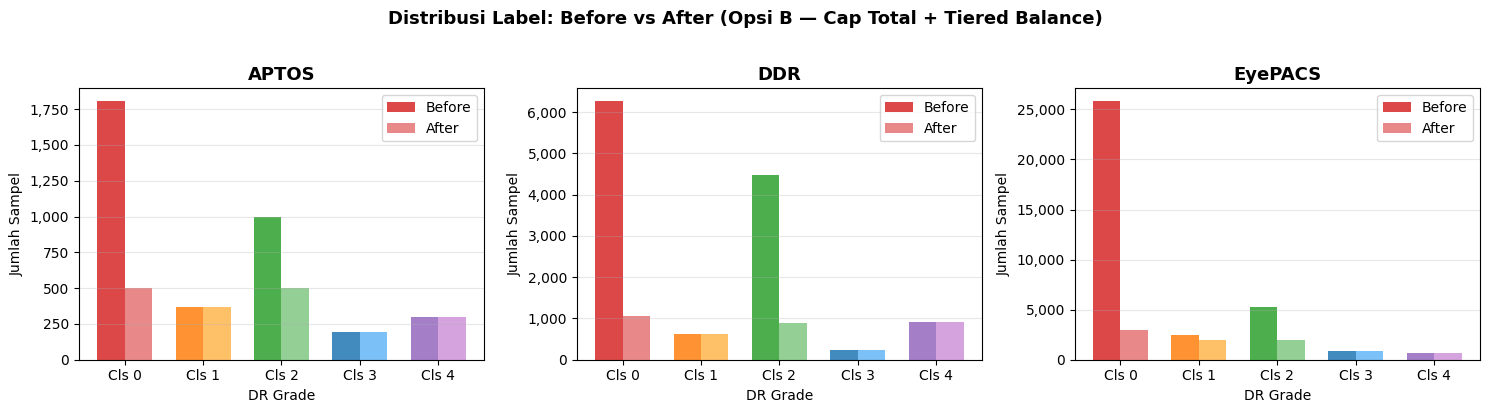

In [ ]:
PROJECT_BASE = "/content/drive/MyDrive/Binus/Semester_4/Research_Methodology"
FIG_DIR = f"{PROJECT_BASE}/Result/preprocessing"
os.makedirs(FIG_DIR, exist_ok=True)

plot_distribution(
    y_before, y_after,
    save_path=f"{FIG_DIR}/rebalancing_before_after.png"
)

## 11. Save Balanced NPZ

In [ ]:
# DDR disave dengan key 'images'/'labels' (konsisten dengan APTOS & EyePACS output)
print("Saving DDR balanced...")
np.savez_compressed(DDR_OUT, images=X_ddr_b, labels=y_ddr_b)
size_mb = os.path.getsize(DDR_OUT) / 1024**2
print(f"  ✅ {DDR_OUT} ({size_mb:.1f} MB)")

print("Saving EyePACS balanced...")
np.savez_compressed(EYEPACS_OUT, images=X_eye_b, labels=y_eye_b)
size_mb = os.path.getsize(EYEPACS_OUT) / 1024**2
print(f"  ✅ {EYEPACS_OUT} ({size_mb:.1f} MB)")

print("Saving APTOS balanced...")
np.savez_compressed(APTOS_OUT, images=X_aptos_b, labels=y_aptos_b)
size_mb = os.path.getsize(APTOS_OUT) / 1024**2
print(f"  ✅ {APTOS_OUT} ({size_mb:.1f} MB)")

print("\n⚠️  Catatan: semua output NPZ pakai key 'images' dan 'labels'")
print("   DDR original pakai key 'X'/'y' — tapi output balanced sudah distandarisasi.")

Saving DDR balanced...
  ✅ /content/drive/MyDrive/S-Class/Orion/OrionFL/balanced/ddr_balanced.npz (413.2 MB)
Saving EyePACS balanced...
  ✅ /content/drive/MyDrive/S-Class/Orion/OrionFL/balanced/eyepacs_balanced.npz (893.4 MB)
Saving APTOS balanced...
  ✅ /content/drive/MyDrive/S-Class/Orion/OrionFL/balanced/aptos_balanced.npz (205.8 MB)

⚠️  Catatan: semua output NPZ pakai key 'images' dan 'labels'
   DDR original pakai key 'X'/'y' — tapi output balanced sudah distandarisasi.


## 12. Verifikasi Output

In [ ]:
print("Verifikasi load balik NPZ output...\n")

for path, name in [(DDR_OUT, "DDR"), (EYEPACS_OUT, "EyePACS"), (APTOS_OUT, "APTOS")]:
    d = np.load(path, allow_pickle=True)
    print(f"  [{name}] keys: {d.files}")

    # Auto-detect key
    X_key = 'images' if 'images' in d.files else 'X'
    y_key = 'labels' if 'labels' in d.files else 'y'

    X_v = d[X_key]
    y_v = d[y_key]
    print(f"    images : {X_v.shape}, dtype={X_v.dtype}, range=[{X_v.min():.3f},{X_v.max():.3f}]")
    print(f"    labels : {y_v.shape}, unique={np.unique(y_v)}")
    counts = Counter(y_v.tolist())
    for cls in sorted(counts):
        print(f"      kelas {cls}: {counts[cls]:,}")
    print()

print("✅ Semua output verified. Siap dipakai di notebook training.")

Verifikasi load balik NPZ output...

  [DDR] keys: ['images', 'labels']
    images : (3729, 224, 224, 3), dtype=float32, range=[0.000,1.000]
    labels : (3729,), unique=[0 1 2 3 4]
      kelas 0: 1,050
      kelas 1: 630
      kelas 2: 900
      kelas 3: 236
      kelas 4: 913

  [EyePACS] keys: ['images', 'labels']
    images : (8581, 224, 224, 3), dtype=float32, range=[0.000,1.000]
    labels : (8581,), unique=[0 1 2 3 4]
      kelas 0: 3,000
      kelas 1: 2,000
      kelas 2: 2,000
      kelas 3: 873
      kelas 4: 708

  [APTOS] keys: ['images', 'labels']
    images : (1858, 224, 224, 3), dtype=float32, range=[0.000,1.000]
    labels : (1858,), unique=[0 1 2 3 4]
      kelas 0: 500
      kelas 1: 370
      kelas 2: 500
      kelas 3: 193
      kelas 4: 295

✅ Semua output verified. Siap dipakai di notebook training.


In [ ]:
# print("Verifikasi load balik NPZ output...\n")

# for path, name in [(APTOS_OUT, "APTOS"), (DDR_OUT, "DDR"), (EYEPACS_OUT, "EyePACS")]:
#     d = np.load(path, allow_pickle=True)
#     X_v = d['images']
#     y_v = d['labels']
#     print(f"  [{name}]")
#     print(f"    images : {X_v.shape}, dtype={X_v.dtype}, range=[{X_v.min():.3f},{X_v.max():.3f}]")
#     print(f"    labels : {y_v.shape}, unique={np.unique(y_v)}")
#     counts = Counter(y_v.tolist())
#     for cls in sorted(counts):
#         print(f"      kelas {cls}: {counts[cls]:,}")
#     print()

# print("✅ Semua output verified. Siap dipakai di notebook training.")

## 13. Summary

In [ ]:
print("=" * 55)
print("  REBALANCING SUMMARY")
print("=" * 55)

datasets = [
    ("APTOS", APTOS_NPZ, APTOS_OUT),
    ("DDR",   DDR_NPZ,   DDR_OUT),
    ("EyePACS", EYEPACS_NPZ, EYEPACS_OUT),
]

for name, orig_path, bal_path in datasets:
    # Load dari file, bukan variabel memory
    orig = np.load(orig_path, allow_pickle=True)
    bal  = np.load(bal_path,  allow_pickle=True)

    y_key_orig = 'labels' if 'labels' in orig.files else 'y'
    y_key_bal  = 'labels' if 'labels' in bal.files  else 'y'

    n_orig = len(orig[y_key_orig])
    n_bal  = len(bal[y_key_bal])
    dropped = n_orig - n_bal
    pct     = dropped / n_orig * 100
    size_mb = os.path.getsize(bal_path) / 1024**2

    print(f"  {name:<10}: {n_orig:>7,} → {n_bal:>7,}  "
          f"(dipotong {dropped:>6,} | {pct:.1f}%)  [{size_mb:.1f} MB]")

print("=" * 55)
print(f"  Output dir: {BALANCED_DIR}")
print("=" * 55)

  REBALANCING SUMMARY
  APTOS     :   3,662 →   1,858  (dipotong  1,804 | 49.3%)  [205.8 MB]
  DDR       :  12,522 →   3,729  (dipotong  8,793 | 70.2%)  [413.2 MB]
  EyePACS   :  35,126 →   8,581  (dipotong 26,545 | 75.6%)  [893.4 MB]
  Output dir: /content/drive/MyDrive/S-Class/Orion/OrionFL/balanced
